In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helgoul packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold, train_test_split, KFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
warnings.filterwarnings('ignore')

# Input data files are available in the read-only '../input/' directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using 'Save & Run All' 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e7/sample_submission.csv
/kaggle/input/playground-series-s5e7/train.csv
/kaggle/input/playground-series-s5e7/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e7/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e7/test.csv')

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [4]:
train.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.000000,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,9261.500000,3.137764,5.265106,4.044319,7.996737,4.982097
std,5347.562529,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,3.000000,3.000000,5.000000,3.000000
50%,9261.500000,2.000000,5.000000,4.000000,8.000000,5.000000
75%,13892.250000,4.000000,8.000000,6.000000,12.000000,7.000000
max,18523.000000,11.000000,10.000000,7.000000,15.000000,10.000000


In [5]:
'''
from ydata_profiling import ProfileReport
train_profile = ProfileReport(train, title='Predict People's Character Report')
train_profile
'''

"\nfrom ydata_profiling import ProfileReport\ntrain_profile = ProfileReport(train, title='Predict People's Character Report')\ntrain_profile\n"

In [6]:
'''
train_profile.to_file('./titanic_train_data_profile.html')
'''

"\ntrain_profile.to_file('./titanic_train_data_profile.html')\n"

◆Profile Reportを見た結果<br>
・特徴量同士の相関が高い<br>
・Stage_fearとDrained_after_socializingの構成はかなり似通っている


In [7]:
# trainとtestを統合する
data = pd.concat([train,test], sort=False)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24699 entries, 0 to 6174
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         24699 non-null  int64  
 1   Time_spent_Alone           23084 non-null  float64
 2   Stage_fear                 22208 non-null  object 
 3   Social_event_attendance    23122 non-null  float64
 4   Going_outside              22767 non-null  float64
 5   Drained_after_socializing  23118 non-null  object 
 6   Friends_circle_size        23295 non-null  float64
 7   Post_frequency             23027 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.9+ MB


In [9]:
print(data.isnull().sum())

id                              0
Time_spent_Alone             1615
Stage_fear                   2491
Social_event_attendance      1577
Going_outside                1932
Drained_after_socializing    1581
Friends_circle_size          1404
Post_frequency               1672
Personality                  6175
dtype: int64


In [10]:
# 分布に基づく欠損値補完関数
def complement_by_distribution(data, column_name):
    '''
    欠損値を現在の分布に基づいてランダムに補完する関数
    カテゴリ変数・量的変数のどちらにも対応

    Parameters:
    - data: pd.DataFrame
    - column_name: str(補完対象の列名)

    Returns:
    - data: pd.DataFrame(補完後のデータ)
    '''

    # 非欠損値の取得
    non_null = data[column_name].dropna()

    # 出現割合の計算（normalize=Trueで確率になる）
    value_counts = non_null.value_counts(normalize=True).sort_index()

    # 値と確率をリストに変換
    values = value_counts.index.tolist()
    probabilities = value_counts.values.tolist()

    # 欠損数の取得
    num_missing = data[column_name].isnull().sum()

    # ランダムに補完値を生成
    complemented_values = np.random.choice(values, size=num_missing, p=probabilities)

    # 補完の適用
    data.loc[data[column_name].isnull(), column_name] = complemented_values

    return data

Drained_after_socializingとStage_fearを元のYes/Noの分布に基づいてランダムに補完する<br>
⇒レポートで欠損値が10％くらいだったので、そこまで分布が変わることはないだろうと判断<br>

In [11]:
# カテゴリ変数の補完
for col in ['Drained_after_socializing', 'Stage_fear']:
    data = complement_by_distribution(data, col)

量的変数の補完を行う<br>
分布が安定しているものは、現在の分布に基づいて欠損値を補完しても問題ないと考えた<br>
分布が安定している=正規分布に近いと定義し、歪度が低いものを現在の分布に基づいて補完する<br>
一般に歪度が±1を超えると強い歪みとされ、±5未満ならほぼ対象と見做される<br>

＜歪度が低いと安定していると言える理由＞<br>
・分布が対象
⇒対称な分布では、代表値（平均・中央値）が一致しやすく、統計的推定が安定する<br>
・モデルが学習しやすい
⇒多くの機械学習モデル（特に線形モデルやニューラルネット）は、対称で連続的な分布を前提にしていることが多い

その他の量的変数については、上記で補完した量的変数とDrained_after_socializing、Stage_fearを用いて予測する<br>
profile reportを見た時に全体的に特徴量間の相関が高かったので予測できるのでは？と考えた<br>
歪度が高い特徴量については、代表値やランダムサンプリングで補完すると偏りを強調してしまったり、歪みを悪化させてしまいそう

In [12]:
# 量的変数の歪度(skewness)をまとめて確認し、歪度が低いものを選定

# 数値型のカラム(今回はfloat型だけ）を抽出
numerical_cols = data.select_dtypes(include=['float64']).columns

# 歪度の計算
skewness = data[numerical_cols].skew()

#結果の表示
print(skewness)

Time_spent_Alone           1.138587
Social_event_attendance   -0.232995
Going_outside             -0.361797
Friends_circle_size       -0.055067
Post_frequency            -0.062806
dtype: float64


Friends_circle_sizeとPost_frequencyの欠損値を現在の分布に基づいて補完する

In [13]:
# 量的変数の補完（歪度が低いもの）
for col in ['Friends_circle_size', 'Post_frequency']:
    data = complement_by_distribution(data, col)

Drained_after_socializing、Stage_fear、Friends_circle_size、Post_frequencyを使って、<br>
Time_spent_Alone 、Social_event_attendance、Going_outsideの欠損値を予測して補完する<br>

補完にはRandomForestRegressorを用いることにした<br>
＜主な理由＞<br>
・非線形関係（複雑なパターン）もとらえることができる<br>
・標準化やスケーリングが不要<br>
・決定木を多数使って平均を取るため過学習のリスクが低い<br>
　⇒補完のような「予測精度よりも安定性が大事」な場面に向いている<br>

Pandas は object → float に暗黙的に変換することがあり、特に NaN を含む列では float64 にされやすいため、intとInt64に変換<br>
Personalityはtest分のNanを含むため、Pandasのnullable Integer型であるInt64を使う

In [14]:
# カテゴリ変数を数値に変換
data['Drained_after_socializing'] = data['Drained_after_socializing'].replace({'Yes': 1, 'No': 0}).astype(int)
data['Stage_fear'] = data['Stage_fear'].replace({'Yes': 1, 'No': 0}).astype(int)
data['Personality'] = data['Personality'].replace({'Extrovert': 1, 'Introvert': 0}).astype('Int64')

In [15]:
# 予測に使う特徴量
input_features = ['Drained_after_socializing', 'Stage_fear', 'Friends_circle_size', 'Post_frequency']

In [16]:
from sklearn.ensemble import RandomForestRegressor

# 欠損値を補完する関数（RandomForestRegressorを使用）
def complement_missing_values(data, target_col, input_cols):
    # 欠損していない行と欠損している行に分ける
    known = data[data[target_col].notnull()]
    missing = data[data[target_col].isnull()]

    # 欠損がある場合のみ補完処理を実行
    if not missing.empty:
        # 学習用データの準備
        X_train_known = known[input_cols]
        y_train_known = known[target_col]

        # モデルの学習
        rf_model = RandomForestRegressor(random_state=42)
        rf_model.fit(X_train_known, y_train_known)

        # 欠損値の予測
        X_missing = missing[input_cols]
        predicted_missing = rf_model.predict(X_missing)

        # 欠損値を補完
        data.loc[data[target_col].isnull(), target_col] = predicted_missing

    return data

In [17]:
# 対象の変数を順に補完処理を実行
for target in ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside']:
    data = complement_missing_values(data, target, input_features)

In [18]:
# 補完後の欠損数を確認
missing_summary = data[['Time_spent_Alone', 'Social_event_attendance', 'Going_outside']].isnull().sum()
print('補完後の欠損値数:')
print(missing_summary)

補完後の欠損値数:
Time_spent_Alone           0
Social_event_attendance    0
Going_outside              0
dtype: int64


2つの特徴量の積を取ることで、「Aが高く、かつBがYesのときに、Cの傾向が強くなる」のような条件付の傾向をモデルに伝える<br>
例）Alone_x_Drained<br>
⇒一人の時間が長く、かつ社交後に疲れる人は、より内向的な傾向が強いと仮定<br>

In [19]:
# 相互作用特徴量(積）の追加
data['Alone_x_Drained'] = data['Time_spent_Alone'] * data['Drained_after_socializing']
data['Alone_x_StageFear'] = data['Time_spent_Alone'] * data['Stage_fear']
data['Social_x_Drained'] = data['Social_event_attendance'] * data['Drained_after_socializing']
data['Social_x_StageFear'] = data['Social_event_attendance'] * data['Stage_fear']
data['Outside_x_Drained'] = data['Going_outside'] * data['Drained_after_socializing']
data['Outside_x_StageFear'] = data['Going_outside'] * data['Stage_fear']

比率系の特徴量を作成することで、相対的な傾向やバランス感覚（非線形的な傾向）をモデルに伝える<br>
例）Time_spent_Alone / Friends_circle_size<br>
⇒一人で過ごす時間が友人の数に対してどれくらい多いか？<br>
比率高：友達が多くても一人の時間を好む→内向的？<br>
比率低：友達が少なくても一人の時間が少ない→外交的？<br>

In [20]:
# 比率系特徴量(商)の追加
data['Alone_/_Friends'] = data['Time_spent_Alone'] / data['Friends_circle_size']
data['Post_/_Friends'] = data['Post_frequency'] / data['Friends_circle_size']
data['Social_/_Outside'] = data['Social_event_attendance'] / data['Going_outside']
data['Alone_/_Social'] = data['Time_spent_Alone'] / data['Social_event_attendance']

In [21]:
# 欠損値の確認
missing_counts = data.isnull().sum()
print(missing_counts)

id                              0
Time_spent_Alone                0
Stage_fear                      0
Social_event_attendance         0
Going_outside                   0
Drained_after_socializing       0
Friends_circle_size             0
Post_frequency                  0
Personality                  6175
Alone_x_Drained                 0
Alone_x_StageFear               0
Social_x_Drained                0
Social_x_StageFear              0
Outside_x_Drained               0
Outside_x_StageFear             0
Alone_/_Friends                11
Post_/_Friends                172
Social_/_Outside              370
Alone_/_Social                  4
dtype: int64


除算の分母が0の場合、inf(無限大)が発生し、学習時にエラーになるので、中央値で補完する<br>
比率系の分布はゆがみやすいので、中央値で補完する<br>
<br>
Alone_/_Friends　　　4 / 24699	　約 0.016%（ほぼなし）<br>
Post_/_Friends	　　176 / 24699	　　約 0.71%（少ない）<br>
Social_/_Outside　　370 / 24699	　約 1.5%（やや少ない）<br>
Alone_/_Social　　　4 / 24699　　約 0.016%（ほぼなし）<br>

In [22]:
# infをNaNに変換
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Personalityを除いた列で各列の中央値を計算
median_values = data.drop(columns=['Personality']).median()

# NaNを列ごとの中央値で補完(Personalityは除外)
data.fillna(value=median_values, inplace=True)

In [23]:
# 欠損値の確認
missing_counts = data.isnull().sum()
print(missing_counts)

id                              0
Time_spent_Alone                0
Stage_fear                      0
Social_event_attendance         0
Going_outside                   0
Drained_after_socializing       0
Friends_circle_size             0
Post_frequency                  0
Personality                  6175
Alone_x_Drained                 0
Alone_x_StageFear               0
Social_x_Drained                0
Social_x_StageFear              0
Outside_x_Drained               0
Outside_x_StageFear             0
Alone_/_Friends                 0
Post_/_Friends                  0
Social_/_Outside                0
Alone_/_Social                  0
dtype: int64


In [24]:
# これまでtrainとtestを連結してきたdataを分割する
train = data[~data['Personality'].isnull()]
test = data[data['Personality'].isnull()].drop(columns=['Personality'])

In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18524 entries, 0 to 18523
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           18524 non-null  float64
 2   Stage_fear                 18524 non-null  int64  
 3   Social_event_attendance    18524 non-null  float64
 4   Going_outside              18524 non-null  float64
 5   Drained_after_socializing  18524 non-null  int64  
 6   Friends_circle_size        18524 non-null  float64
 7   Post_frequency             18524 non-null  float64
 8   Personality                18524 non-null  Int64  
 9   Alone_x_Drained            18524 non-null  float64
 10  Alone_x_StageFear          18524 non-null  float64
 11  Social_x_Drained           18524 non-null  float64
 12  Social_x_StageFear         18524 non-null  float64
 13  Outside_x_Drained          18524 non-null  float64


In [26]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6175 entries, 0 to 6174
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         6175 non-null   int64  
 1   Time_spent_Alone           6175 non-null   float64
 2   Stage_fear                 6175 non-null   int64  
 3   Social_event_attendance    6175 non-null   float64
 4   Going_outside              6175 non-null   float64
 5   Drained_after_socializing  6175 non-null   int64  
 6   Friends_circle_size        6175 non-null   float64
 7   Post_frequency             6175 non-null   float64
 8   Alone_x_Drained            6175 non-null   float64
 9   Alone_x_StageFear          6175 non-null   float64
 10  Social_x_Drained           6175 non-null   float64
 11  Social_x_StageFear         6175 non-null   float64
 12  Outside_x_Drained          6175 non-null   float64
 13  Outside_x_StageFear        6175 non-null   float64
 1

In [27]:
# データセットの作成
X_train = train.drop(columns=['id', 'Personality'])
y_train = train['Personality']
id_train = train['id']

In [28]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
# 手動で設定するハイパーパラメータ
params_lgb = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'binary_logloss',
    'verbosity': -1,
    'random_state': 42,
    'importance_type': 'gain',
    'n_estimators': 1000,
    'class_weight': 'balanced'
}

# ハイパーパラメータの探索範囲を設定
param_distributions_lgb = {
    'num_leaves': [20, 31, 50],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 10]
}


lgb_model = lgb.LGBMClassifier(**params_lgb)


# ランダムサーチを実行
random_search_lgb = RandomizedSearchCV(estimator=lgb_model,
                                       param_distributions=param_distributions_lgb,
                                       n_iter=10,
                                       scoring='accuracy',
                                       cv=StratifiedKFold(n_splits=3),
                                       verbose=-1,
                                       random_state=42,
                                       n_jobs=-1,
                                       return_train_score=True
                                      )

random_search_lgb.fit(X_train, y_train)

# best_indexを取得
best_index_lgb = random_search_lgb.best_index_
# 対応するtrainスコアを取得
train_score_lgb = random_search_lgb.cv_results_['mean_train_score'][best_index_lgb]
# Gapの計算
gap_lgb = train_score_lgb - random_search_lgb.best_score_


# best_paramsとbest_scoreの表示
print('Best parameters found (LightGBM): ', random_search_lgb.best_params_)
print('Best accuracy found (LightGBM): ', random_search_lgb.best_score_)
print('Train Score (LightGBM):',train_score_lgb )
print('Gap (LightGBM):',gap_lgb)

Best parameters found (LightGBM):  {'num_leaves': 31, 'max_depth': 5, 'learning_rate': 0.05}
Best accuracy found (LightGBM):  0.9652884085322323
Train Score (LightGBM): 0.98318400884575
Gap (LightGBM): 0.017895600313517668


In [29]:
import xgboost as xgb
# 手動で設定するハイパーパラメータ
params_xgb = {
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_estimators': 1000
}

# ハイパーパラメータの探索範囲を設定
param_distributions_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

xgb_model = xgb.XGBClassifier(**params_xgb)

# ランダムサーチを実行
random_search_xgb = RandomizedSearchCV(estimator=xgb_model,
                                      param_distributions=param_distributions_xgb,
                                      n_iter=10,
                                      scoring='accuracy',
                                      cv=StratifiedKFold(n_splits=3),
                                      verbose=-1,
                                      random_state=42,
                                      n_jobs=-1,
                                      return_train_score=True
                                     )


random_search_xgb.fit(X_train, y_train)

# best_indexを取得
best_index_xgb = random_search_xgb.best_index_
# 対応するtrainスコアを取得
train_score_xgb = random_search_xgb.cv_results_['mean_train_score'][best_index_xgb]
# Gapの計算
gap_xgb = train_score_xgb - random_search_xgb.best_score_


# best_paramsとbest_scoreの表示
print('Best parameters found (XGBoost)', random_search_xgb.best_params_)
print('Best accuracy found (XGBoost)', random_search_xgb.best_score_)
print('Train Score (XGBoost):',train_score_xgb )
print('Gap (XGBoost):',gap_xgb)

Best parameters found (XGBoost) {'subsample': 0.6, 'max_depth': 3, 'learning_rate': 0.05}
Best accuracy found (XGBoost) 0.9679335964190958
Train Score (XGBoost): 0.9713075096968956
Gap (XGBoost): 0.0033739132777997893


In [30]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier

# 手動で設定する基本パラメータ
params_rf = {
    'random_state': 42,
    'n_estimators': 1000
}

# ハイパーパラメータの探索範囲を設定
param_distributions_rf = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestClassifier(**params_rf)

# ランダムサーチを実行
random_search_rf = RandomizedSearchCV(estimator=rf_model,
                                      param_distributions=param_distributions_rf,
                                      scoring='accuracy',
                                      cv=StratifiedKFold(n_splits=3),
                                      verbose=-1,
                                      random_state=42,
                                      n_jobs=-1,
                                      return_train_score=True
                                     )

random_search_rf.fit(X_train, y_train)

# best_indexを取得
best_index_rf = random_search_rf.best_index_
# 対応するtrainスコアを取得
train_score_rf = random_search_rf.cv_results_['mean_train_score'][best_index_rf]
# Gapの計算
gap_rf = train_score_rf - random_search_rf.best_score_


# best_paramsとbest_scoreの表示
print('Best parameters found (RandomForest)', random_search_rf.best_params_)
print('Best accuracy found (RandomForest)', random_search_rf.best_score_)
print('Train Score (RandomForest):',train_score_rf )
print('Gap (RandomForest):',gap_rf)

Best parameters found (RandomForest) {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 10}
Best accuracy found (RandomForest) 0.9689593248776922
Train Score (RandomForest): 0.9698769469878998
Gap (RandomForest): 0.0009176221102076276


In [31]:
# 最適パラメータの取得とモデル再訓練

# 最適なハイパーパラメータをparamsに追加
best_params_lgb = random_search_lgb.best_params_
params_lgb.update(best_params_lgb)

# 最適なハイパーパラメータでモデルを再訓練
best_model_lgb = lgb.LGBMClassifier(**params_lgb)
best_model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(0)
    ]
)

LGBMClassifier(class_weight='balanced', importance_type='gain',
               learning_rate=0.05, max_depth=5, metric='binary_logloss',
               n_estimators=1000, objective='binary', random_state=42,
               verbosity=-1)

In [32]:
best_params_xgb = random_search_xgb.best_params_
params_xgb.update(best_params_xgb)
best_xgb_model = xgb.XGBClassifier(**params_xgb)
best_xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [33]:
best_params_rf = random_search_rf.best_params_
params_rf.update(best_params_rf)
best_rf_model = RandomForestClassifier(**params_rf)
best_rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=5,
                       n_estimators=1000, random_state=42)

In [34]:
# 推論用データセットの作成
X_test = test.drop(columns=['id'])
id_test = test['id'] 

In [35]:
# VotingClassifier の定義（最適化済みモデルを使用）
voting_model = VotingClassifier(
    estimators=[
        ('lgb', best_model_lgb),
        ('xgb', best_xgb_model),
        ('rf', best_rf_model)
    ],
    voting='soft'
)

# 交差検証で評価
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(voting_model, X_train, y_train, cv=cv, scoring='accuracy')
print(f'[VotingClassifier Cross-Validation Results]')
print(f'Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# モデルの学習と予測
voting_model.fit(X_train, y_train)
y_test_pred = voting_model.predict(X_test)


[VotingClassifier Cross-Validation Results]
Accuracy: 0.9685 ± 0.0023


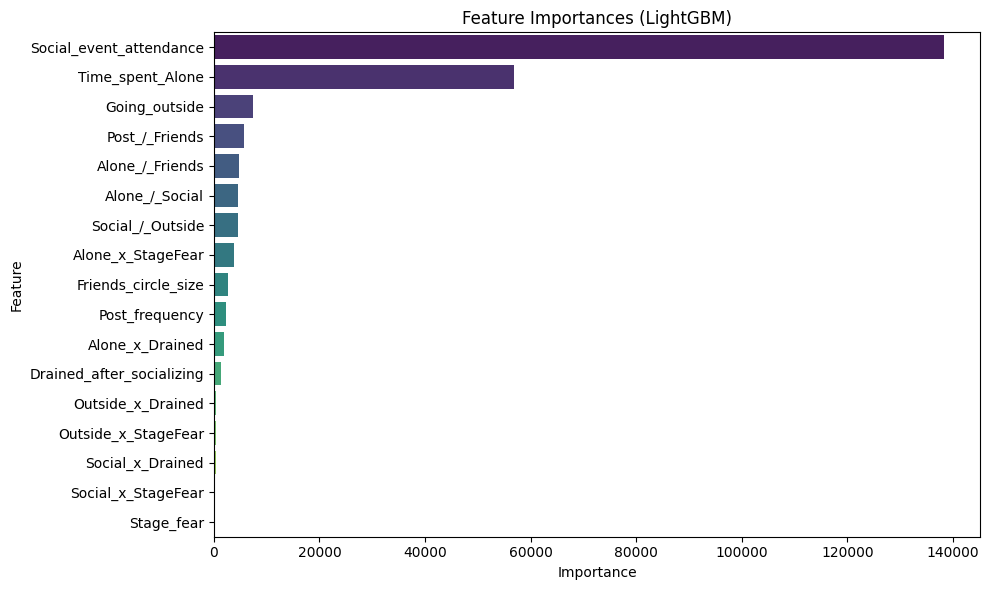

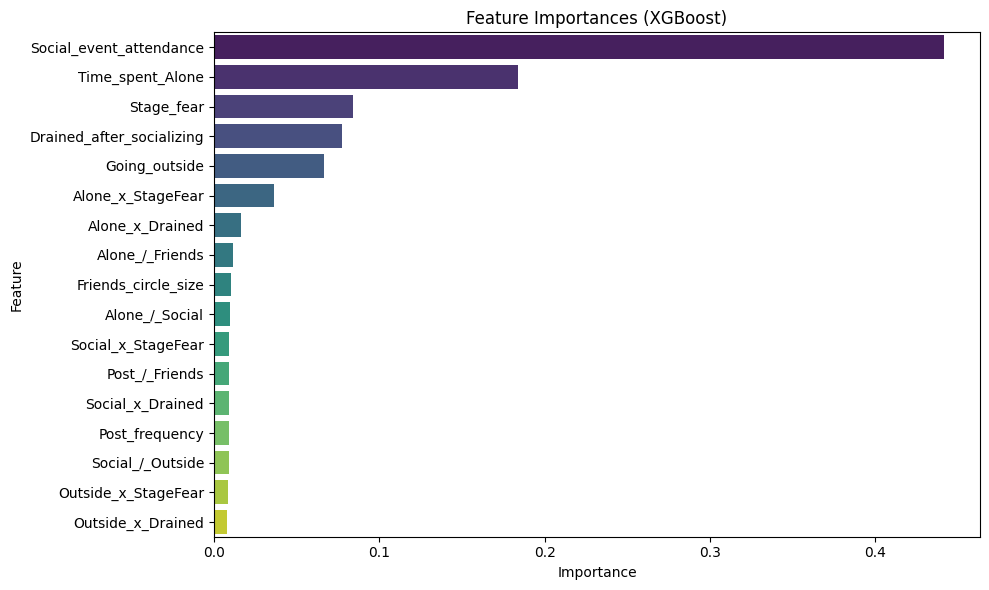

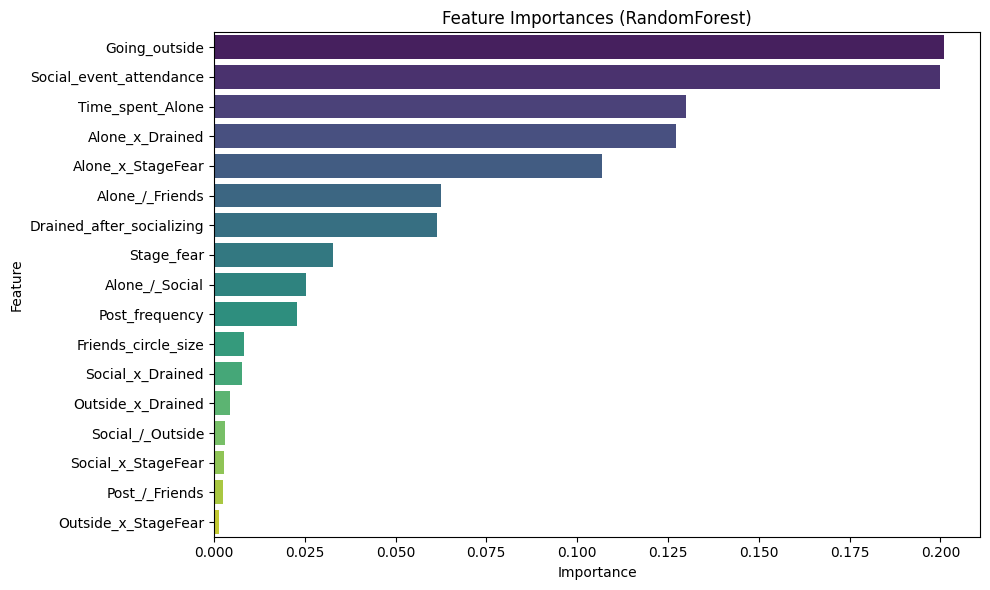

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, model_name, feature_names):
    if hasattr(model, 'feature_importances_'):
        importance = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
        plt.title(f'Feature Importances ({model_name})')
        plt.tight_layout()
        plt.show()

# 各モデルの重要度を表示
plot_feature_importance(best_model_lgb, 'LightGBM', X_train.columns)
plot_feature_importance(best_xgb_model, 'XGBoost', X_train.columns)
plot_feature_importance(best_rf_model, 'RandomForest', X_train.columns)


In [37]:
# id_testをDataFrameに変換する
id_test_df = pd.DataFrame({'id': id_test.values})  # または id_test.reset_index(drop=True)

# 予測結果をまとめる
submit = pd.DataFrame({'id': id_test_df['id'], 'Personality': pd.Series(y_test_pred).replace({1: 'Extrovert', 0: 'Introvert'})
                      })
display(submit.head())
submit.to_csv('submission_baseline.csv', index=None)

,id,Personality
0,18524,Extrovert
1,18525,Introvert
2,18526,Extrovert
3,18527,Extrovert
4,18528,Introvert
